In [19]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Base directory for your project
BASE_DIR = Path(r"C:\Users\Kifiya_Administrator\Desktop\New Task\brent-oil-change-point-analysis-1")

# File paths
RAW_PATH = BASE_DIR / "data" / "raw" / "BrentOilPrices.csv"
EVENTS_PATH = BASE_DIR / "data" / "events" / "oil_market_events.csv"


In [20]:
# Check if the file exists
print("BrentOilPrices.csv exists:", RAW_PATH.exists())

# Print first few lines to see content
with open(RAW_PATH, 'r') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 5:  # show first 6 lines
            break


BrentOilPrices.csv exists: True
Date,Price
20-May-87,18.63
21-May-87,18.45
22-May-87,18.55
25-May-87,18.6
26-May-87,18.63


In [21]:
# Try to load CSV with header
try:
    df = pd.read_csv(RAW_PATH)
except pd.errors.EmptyDataError:
    print("Empty CSV or missing header. Loading with default column names.")
    df = pd.read_csv(RAW_PATH, header=None, names=['date', 'price'])

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

print(df.head())


        date  price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63


C:\Users\Kifiya_Administrator\AppData\Local\Temp\ipykernel_21416\2557304586.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [22]:
# Check if events file exists
print("Events file exists:", EVENTS_PATH.exists())

# Load events CSV
try:
    events = pd.read_csv(EVENTS_PATH)
except pd.errors.EmptyDataError:
    print("Events CSV is empty or missing header. Creating example events.")
    # Example placeholder events
    events_data = [
        ['2011-02-15', 'Libyan Civil War begins'],
        ['2014-11-27', 'OPEC decision to maintain production'],
        ['2016-01-16', 'Iran sanctions lifted'],
        ['2016-11-30', 'OPEC production cut agreement'],
        ['2018-05-08', 'US withdraws from Iran nuclear deal'],
        ['2020-03-08', 'Saudi-Russia oil price war'],
        ['2020-03-11', 'COVID-19 declared pandemic'],
        ['2020-04-12', 'Historic OPEC+ production cuts'],
        ['2021-10-01', 'Global energy supply crisis'],
        ['2022-02-24', 'Russia-Ukraine war begins']
    ]
    events = pd.DataFrame(events_data, columns=['date', 'event'])

# Clean event data
events.columns = events.columns.str.strip().str.lower()
events['date'] = pd.to_datetime(events['date'], errors='coerce')
events = events.dropna(subset=['date']).sort_values('date').reset_index(drop=True)

print(events.head())


Events file exists: True
Events CSV is empty or missing header. Creating example events.
        date                                 event
0 2011-02-15               Libyan Civil War begins
1 2014-11-27  OPEC decision to maintain production
2 2016-01-16                 Iran sanctions lifted
3 2016-11-30         OPEC production cut agreement
4 2018-05-08   US withdraws from Iran nuclear deal


In [23]:
df['log_return'] = np.log(df['price']).diff()
df = df.dropna()
print(df.head())


        date  price  log_return
1 1987-05-21  18.45   -0.009709
2 1987-05-22  18.55    0.005405
3 1987-05-25  18.60    0.002692
4 1987-05-26  18.63    0.001612
5 1987-05-27  18.60   -0.001612


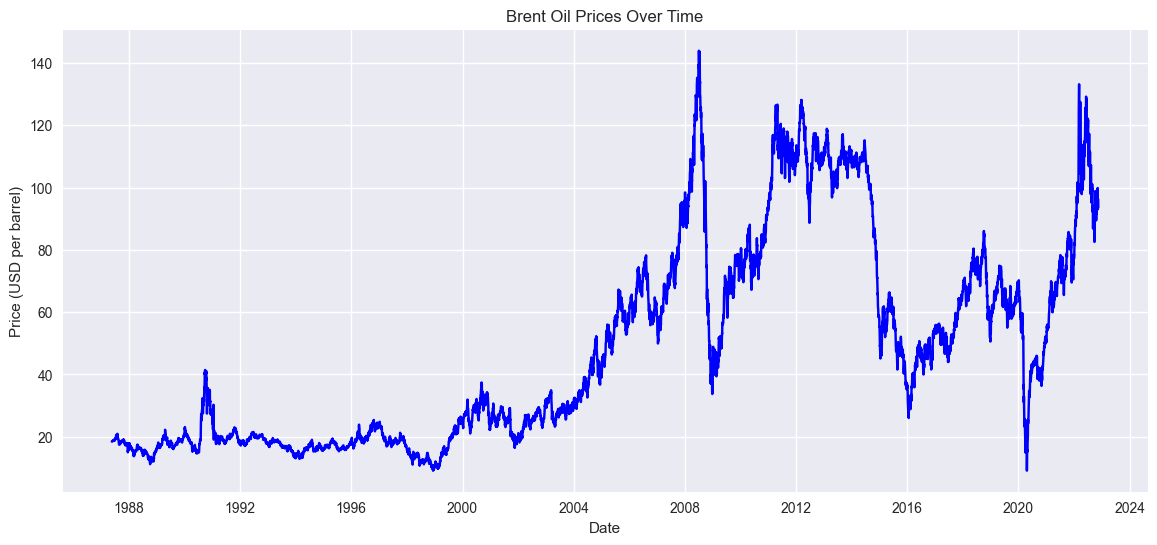

In [24]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['price'], color='blue')
plt.title("Brent Oil Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.grid(True)
plt.show()


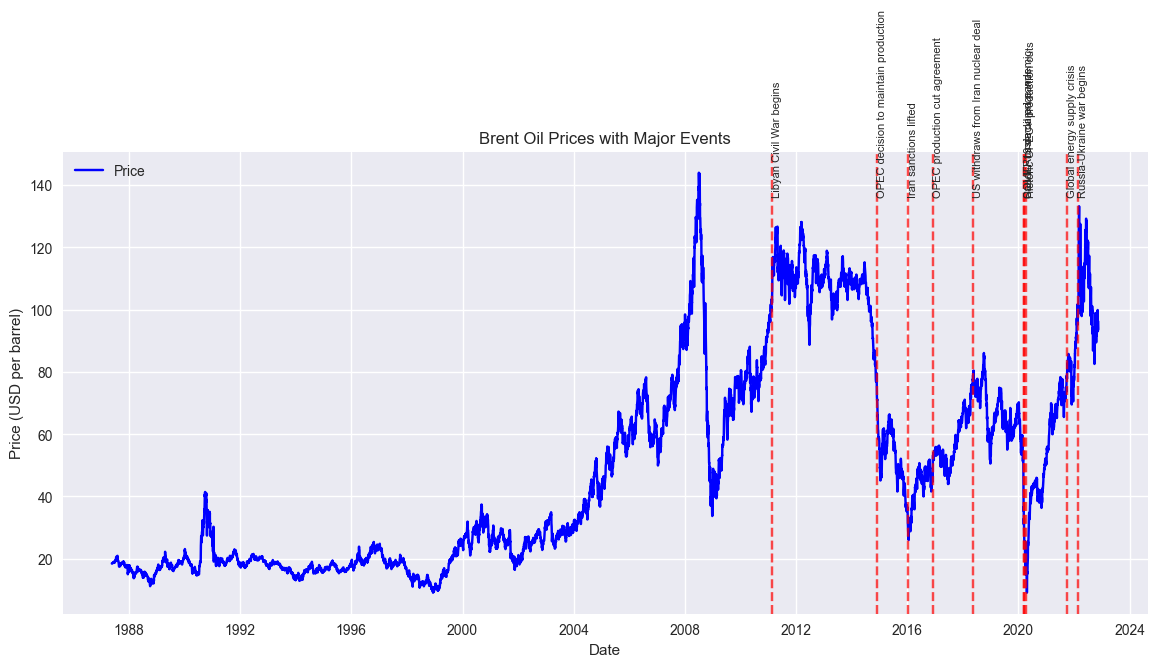

In [25]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['price'], color='blue', label='Price')

# Overlay events
for _, row in events.iterrows():
    plt.axvline(row['date'], color='red', linestyle='--', alpha=0.7)
    plt.text(row['date'], df['price'].max()*0.95, row['event'], rotation=90, fontsize=8)

plt.title("Brent Oil Prices with Major Events")
plt.xlabel("Date")
plt.ylabel("Price (USD per barrel)")
plt.legend()
plt.grid(True)
plt.show()


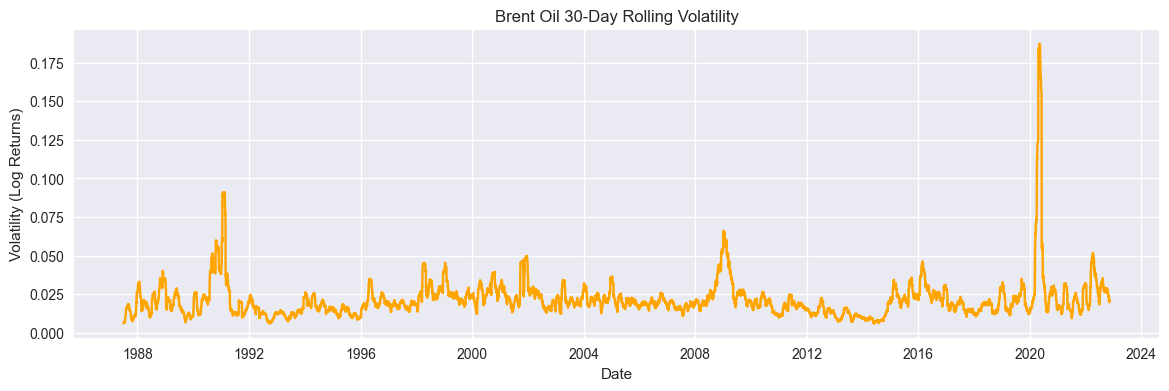

In [26]:
df['volatility'] = df['log_return'].rolling(window=30).std()

plt.figure(figsize=(14,4))
plt.plot(df['date'], df['volatility'], color='orange')
plt.title("Brent Oil 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Log Returns)")
plt.grid(True)
plt.show()


In [27]:
df.to_csv(BASE_DIR / "data" / "raw" / "BrentOilPrices_cleaned.csv", index=False)
